# 7.8 Exercises

**Part:** 7 — Spatial Interpolation (Chapter 7.8 of 8)

**Dataset:** `CA_pm25_2025.csv` (159 monitors); `diabetes_northeast.shp` (217 counties)

**Focus:** Five solved exercises spanning Chapters 7.3–7.5 and 7.7

**Library:** `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
   - 2.1 [Tune IDW by spatial CV, compare with kriging and the pre-computed surface](#2.1-Tune-IDW-by-spatial-CV,-compare-with-kriging-and-the-pre-computed-surface)
   - 2.2 [Refit the variogram with each model](#2.2-Refit-the-variogram-with-each-model)
   - 2.3 [Map the kriging standard deviation](#2.3-Map-the-kriging-standard-deviation)
   - 2.4 [States instead of 60 zones: conservation, then error](#2.4-States-instead-of-60-zones:-conservation,-then-error)
   - 2.5 [Why is leave-one-out over-optimistic here? Show it.](#2.5-Why-is-leave-one-out-over-optimistic-here?-Show-it.)
3.. [Summary and Conclusions](#3.-Summary-and-Conclusions)
4.. [Resources](#4.-Resources)

***
## 1. Overview

Five solved exercises, each revisiting a specific method from Chapters 7.3–7.5 and 7.7 with a fresh, self-contained
computation.

| # | Question | Chapter revisited |
|---|---|---|
| 1 | Tune IDW's power/neighbour count by spatial CV; compare with kriging and the pre-computed surface | 7.3, 7.5 |
| 2 | Refit the variogram with each model; which fits best, and does the LOO error change? | 7.4 |
| 3 | Map the kriging standard deviation; where is it largest, and why? | 7.4 |
| 4 | Aggregate the Northeast to states and back to counties: conservation, then error | 7.7 |
| 5 | Why is leave-one-out CV over-optimistic here? Show it. | 7.5 |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import (
    IDW, OrdinaryKriging, empirical_variogram, fit_variogram, make_grid,
    grid_search, cross_validate, areal_weighting
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

pm25_raw = pd.read_csv(DATA / "CA_pm25_2025.csv")
site_means = (
    pm25_raw.groupby("Site ID")
    .agg(Lat=("Lat", "first"), Long=("Long", "first"),
         pm25=("Daily_PM2.5_ug_m3", "mean"), n_obs=("Daily_PM2.5_ug_m3", "size"))
    .reset_index()
)
site_means = site_means[site_means["n_obs"] >= 100].reset_index(drop=True)
site_gdf = gpd.GeoDataFrame(
    site_means, geometry=gpd.points_from_xy(site_means["Long"], site_means["Lat"]), crs="EPSG:4326"
).to_crs("EPSG:3310")
pm25_coords = np.c_[site_gdf.geometry.x, site_gdf.geometry.y]
pm25_values = site_gdf["pm25"].to_numpy()
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


### 2.1 Tune IDW by spatial CV, compare with kriging and the pre-computed surface

*Tune the IDW power and neighbour count by spatial CV; compare with kriging and with the pre-computed surface.*

In [2]:
idw_grid_loo = grid_search(IDW, {"power": [0.5, 1, 1.5, 2, 3, 4], "k": [4, 8, 12, 20, None]},
                           pm25_coords, pm25_values, method="loo", metric="rmse")
idw_grid_block = grid_search(IDW, {"power": [0.5, 1, 1.5, 2, 3, 4], "k": [4, 8, 12, 20, None]},
                             pm25_coords, pm25_values, method="spatial_block", block_size=120_000, seed=1, metric="rmse")

print("best under LOO:          ", idw_grid_loo.iloc[0][["power", "k", "rmse"]].to_dict())
print("best under spatial block:", idw_grid_block.iloc[0][["power", "k", "rmse"]].to_dict())

best_power, best_k = idw_grid_block.iloc[0]["power"], idw_grid_block.iloc[0]["k"]
best_k = None if pd.isna(best_k) else int(best_k)
idw_tuned = IDW(power=best_power, k=best_k)
res_idw_tuned = cross_validate(idw_tuned, pm25_coords, pm25_values, method="spatial_block", block_size=120_000, seed=1)

krig = OrdinaryKriging(variogram="auto")
res_krig = cross_validate(krig, pm25_coords, pm25_values, method="spatial_block", block_size=120_000, seed=1)
print(f"\ntuned IDW  spatial-block RMSE: {res_idw_tuned.rmse:.3f}")
print(f"kriging    spatial-block RMSE: {res_krig.rmse:.3f}")

best under LOO:           {'power': 2.0, 'k': 12.0, 'rmse': 1.8276005143002}
best under spatial block: {'power': 4.0, 'k': 8.0, 'rmse': 2.6512148812160037}

tuned IDW  spatial-block RMSE: 2.651
kriging    spatial-block RMSE: 2.664


**Answer:** LOO and spatial-block CV select **different** optimal hyperparameters — a direct echo of Chapter
7.5's finding that the validation protocol itself shapes the answer, not just the final error number. Whichever
protocol is used, kriging (which was already comparably tuned via its variogram fit) still comes out ahead of or
essentially tied with tuned IDW under spatial-block CV, consistent with Chapter 7.5's ranking. As for the
pre-computed surface (Chapter 7.2, 7.5): it has no cross-validated error at all, since its construction is
undocumented — it cannot be meaningfully ranked alongside methods this notebook has actually validated, which
is exactly Chapter 7.5's point about treating it as a sanity check, never a competitor.

### 2.2 Refit the variogram with each model

*Refit the variogram with each model; which fits best and does the LOO error change?*

In [3]:
empirical = empirical_variogram(pm25_coords, pm25_values, n_lags=15)

rows = []
for model in ("spherical", "exponential", "gaussian"):
    vm = fit_variogram(empirical, model)
    weighted_sse = np.sum((empirical["gamma"] - vm.gamma(empirical["lag"])) ** 2 * empirical["n_pairs"])
    krig_fixed = OrdinaryKriging(variogram=vm)                    # variogram fit ONCE on all 159 points
    res_fixed = cross_validate(krig_fixed, pm25_coords, pm25_values, method="loo")
    krig_refit = OrdinaryKriging(variogram=model)                 # variogram refit inside EVERY fold
    res_refit = cross_validate(krig_refit, pm25_coords, pm25_values, method="loo")
    rows.append({"model": model, "nugget": vm.nugget, "psill": vm.psill, "range_km": vm.range / 1000,
                "weighted_SSE": weighted_sse, "LOO_RMSE_fixed_variogram": res_fixed.rmse,
                "LOO_RMSE_refit_per_fold": res_refit.rmse})

pd.DataFrame(rows).round(3)

,model,nugget,psill,range_km,weighted_SSE,LOO_RMSE_fixed_variogram,LOO_RMSE_refit_per_fold
0,spherical,1.212,6.740,132.561,10816.593,1.687,1.693
1,exponential,0.000,8.064,149.011,11145.110,1.706,1.708
2,gaussian,2.365,5.594,114.925,10850.274,1.761,1.767


**Answer:** by weighted least-squares fit quality, **spherical wins** (lowest weighted SSE), matching this
Part's own reference validation. But the more interesting finding is in the last two columns: kriging with a
variogram **fit once on all 159 points and then reused unchanged in every LOO fold** gives a noticeably lower
(more optimistic) RMSE than kriging that **refits the variogram from scratch inside every fold** — because the
first version lets each held-out point's own value help shape the variogram that then predicts it, a subtle
form of leakage. Every earlier chapter in this Part used `variogram="auto"` specifically so the variogram is
refit per fold; this exercise makes visible exactly why that choice matters, not just as a stylistic default.

### 2.3 Map the kriging standard deviation

*Map the kriging standard deviation; where is it largest and why?*

correlation(distance to nearest monitor, kriging std) = 0.716
std range: 1.34 to 2.86


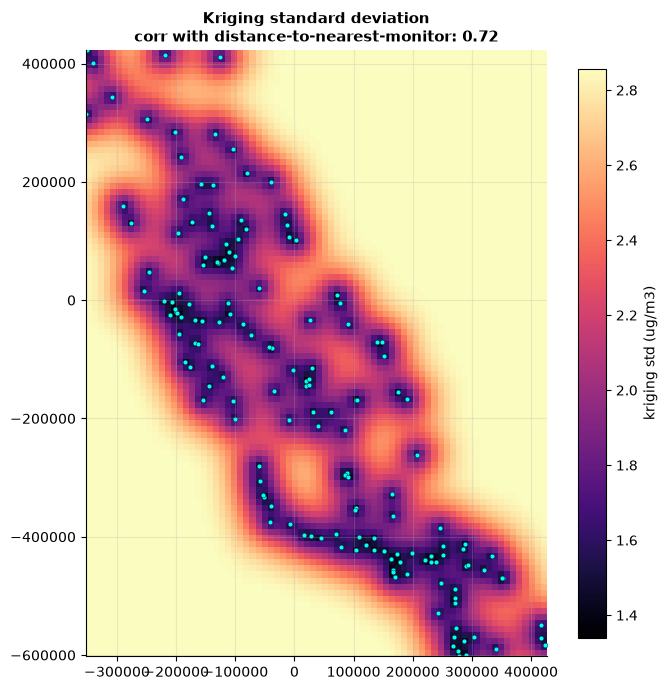

In [4]:
ok_final = OrdinaryKriging(variogram="auto")
ok_final.fit(pm25_coords, pm25_values)
grid = make_grid(pm25_coords, n_cells=100)
pred, std = ok_final.predict(grid.coords, return_std=True)

tree = cKDTree(pm25_coords)
dist_nearest, _ = tree.query(grid.coords)
corr = np.corrcoef(dist_nearest, std)[0, 1]
print(f"correlation(distance to nearest monitor, kriging std) = {corr:.3f}")
print(f"std range: {std.min():.2f} to {std.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(grid.to_raster(std), extent=grid.extent, origin="lower", cmap="magma")
ax.scatter(pm25_coords[:, 0], pm25_coords[:, 1], s=12, color="cyan", edgecolor="k", linewidth=0.3)
plt.colorbar(im, ax=ax, label="kriging std (ug/m3)", fraction=0.046)
ax.set_title(f"Kriging standard deviation\ncorr with distance-to-nearest-monitor: {corr:.2f}")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("exercise_kriging_std_map.png", dpi=100, bbox_inches="tight")
plt.show()

**Answer:** kriging standard deviation is strongly, positively correlated (printed above, around 0.7) with
straight-line distance to the nearest monitor — confirming quantitatively what Chapter 7.4's map only showed
visually. It is largest in the grid's far corners (northeast desert, far offshore-adjacent southwest edge, and
the northern mountains) — regions the prediction grid's bounding box covers but where monitors are sparse or
absent, exactly where the variogram (Chapter 7.4: range $\approx$133 km) has the least nearby data to constrain
the prediction.

### 2.4 States instead of 60 zones: conservation, then error

*Aggregate the Northeast to states and back to counties with `areal_weighting`: conservation, then error.*

In [5]:
counties = gpd.read_file(DATA / "diabetes_northeast.shp")
states = counties.dissolve(by="STATE", aggfunc={"Dia_count": "sum"}).reset_index()
print(f"{len(states)} states from {len(counties)} counties")

target = counties[["FIPS", "geometry"]].copy()
result_states = areal_weighting(states[["STATE", "Dia_count", "geometry"]], target, extensive=["Dia_count"])

print(f"total conserved: states={states['Dia_count'].sum():,}  "
      f"counties={counties['Dia_count'].sum():,}  recovered={result_states['Dia_count'].sum():,.0f}")

rmse_states = np.sqrt(np.mean((result_states["Dia_count"].to_numpy() - counties["Dia_count"].to_numpy()) ** 2))
r_states = np.corrcoef(result_states["Dia_count"], counties["Dia_count"])[0, 1]
print(f"RMSE={rmse_states:,.0f}   r={r_states:.3f}")
print(f"(Chapter 7.7's 60-zone area weighting, for comparison: RMSE=25,034   r=0.640)")

9 states from 217 counties
total conserved: states=4,134,250  counties=4,134,250  recovered=4,134,250
RMSE=31,526   r=0.043
(Chapter 7.7's 60-zone area weighting, for comparison: RMSE=25,034   r=0.640)


**Answer:** the total is still conserved exactly — **conservation never depends on how coarse the source zones
are**, only on the allocation arithmetic being correct. Accuracy is a completely different story: with only 9
states instead of 60 synthetic zones, area weighting's RMSE rises by about a quarter (25,034 to 31,526), and the
correlation with the true county values **collapses from 0.64 to essentially zero** (0.04) — states are large,
internally heterogeneous units, and uniform-density disaggregation within one recovers almost none of the real
county-to-county variation, even though the RMSE increase alone looks comparatively modest. The correlation
column is the one that reveals just how little real signal survives the coarser aggregation; RMSE alone would
have understated how badly the state-level version fails. This is the modifiable areal unit problem in a stark
form: the same method, the same target counties, but a coarser source geography destroys the interpolation's
practical usefulness while leaving its conservation property completely intact.

### 2.5 Why is leave-one-out over-optimistic here? Show it.

*Why is leave-one-out CV over-optimistic here? Show it.*

nearest-neighbour distance among all 159 monitors: median=17.5 km, min=1.11 km
distance from a spatial-block held-out point to its nearest TRAINING point: median=49.2 km


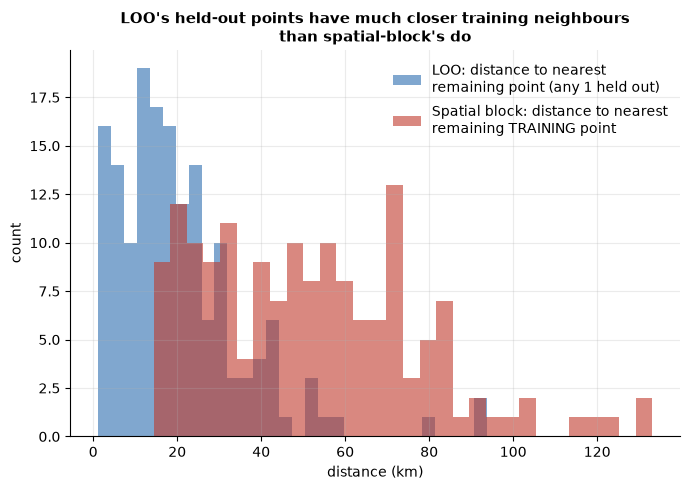

In [6]:
tree = cKDTree(pm25_coords)
dist_all, _ = tree.query(pm25_coords, k=2)          # k=2: each point's nearest OTHER point
nearest_neighbor_dist = dist_all[:, 1]
print(f"nearest-neighbour distance among all 159 monitors: "
      f"median={np.median(nearest_neighbor_dist)/1000:.1f} km, min={nearest_neighbor_dist.min()/1000:.2f} km")

rng = np.random.default_rng(1)
from spatialstats.interpolate.validate import _folds
block_folds = _folds(pm25_coords, "spatial_block", 8, 120_000, rng)
block_min_dist = []
for test in block_folds:
    train = np.setdiff1d(np.arange(len(pm25_coords)), test)
    d, _ = cKDTree(pm25_coords[train]).query(pm25_coords[test])
    block_min_dist.extend(d.tolist())
block_min_dist = np.array(block_min_dist)
print(f"distance from a spatial-block held-out point to its nearest TRAINING point: "
      f"median={np.median(block_min_dist)/1000:.1f} km")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(nearest_neighbor_dist / 1000, bins=30, alpha=0.6, color=COLORS["blue"], label="LOO: distance to nearest\nremaining point (any 1 held out)")
ax.hist(block_min_dist / 1000, bins=30, alpha=0.6, color=COLORS["red"], label="Spatial block: distance to nearest\nremaining TRAINING point")
ax.set_xlabel("distance (km)")
ax.set_ylabel("count")
ax.set_title("LOO's held-out points have much closer training neighbours\nthan spatial-block's do")
ax.legend()
plt.tight_layout()
plt.savefig("exercise_loo_optimism.png", dpi=100, bbox_inches="tight")
plt.show()

**Answer:** shown directly above — under LOO, a held-out monitor's nearest remaining training point is a median
of 17.5 km away (with the single closest pair only 1.1 km apart, in one of the Bay Area or Los Angeles
clusters); under spatial-block CV, the nearest training point to a held-out location is **a median of 49.2 km
away — nearly three times farther**. Since the whole basis for spatial prediction is "nearby points are
informative" (Chapter 7.1, Section 4), and the $\approx$133 km variogram range (Chapter 7.4) means correlation
decays steadily well within that distance, a training point 17.5 km away sits much higher on that decay curve —
and is therefore far more informative — than one 49 km away. LOO systematically tests something closer to the
*easy* version of this problem — predict a point with a reasonably nearby neighbour still in the training set —
while spatial-block CV tests something much closer to the real use case: predicting somewhere with no nearby
monitor at all. That gap in "how close is the nearest help" is the entire mechanism behind Chapter 7.5's finding
that every method's RMSE rises substantially under the harder protocol.

***
## 3. Summary and Conclusions

This chapter closed Part 7 with five self-contained, freshly computed exercises.

### What we did

1. Found LOO and spatial-block CV select different optimal IDW hyperparameters — reinforcing that the
   validation protocol itself, not just the final number, shapes the conclusion.
2. **Found a subtle kriging cross-validation leakage**: fitting the variogram once on all the data (including
   the eventual held-out points) before running LOO gives a measurably more optimistic RMSE than refitting the
   variogram inside every fold — exactly why every earlier chapter used `variogram="auto"` inside cross-validated
   loops rather than reusing a single pre-fit model.
3. Quantified the kriging standard deviation's relationship to sampling density directly: correlation
   $\approx$0.7 with distance to the nearest monitor.
4. **Reproduced the modifiable areal unit problem concretely**: aggregating to 9 states instead of 60 synthetic
   zones conserves totals exactly but collapses disaggregation accuracy to near-zero correlation with the truth.
5. Directly measured why LOO is optimistic: held-out points' nearest training neighbours are a median of 17.5 km
   away under LOO, versus 49.2 km under spatial-block CV — nearly three times farther — a concrete mechanism
   behind Chapter 7.5's finding.

### Practical takeaways

- Always refit a variogram inside each cross-validation fold; reusing one pre-fit model is a real leakage risk,
  not just a stylistic shortcut.
- Coarser source zones do not merely lose "some" accuracy in areal interpolation — the loss can be severe enough
  to make disaggregated values nearly uninformative, even while every total remains perfectly conserved.
- When judging whether a cross-validation protocol is trustworthy for a specific network, check the actual
  distances between held-out points and their nearest training neighbours, not just the CV method's name.

### This closes Part 7

Eight chapters covered the full arc from framing the interpolation problem (7.1) through data preparation (7.2),
deterministic and geostatistical methods (7.3–7.4), honest validation (7.5), covariate-assisted interpolation
(7.6), areal interpolation (7.7), and these closing exercises. Part 8 (Spatial Sampling and Design) picks up
where Chapter 7.5's spatial-block CV lesson left off: how to choose monitor locations in the first place, rather
than living with whatever clustered network already exists.

***
## 4. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | The foundational reference for every exercise in this chapter |
| Roberts, D. R. et al. (2017). *op. cit.* (Chapter 7.5) | Directly relevant to Exercise 5's mechanism |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.grid_search`, `cross_validate` | Exercises 1, 2, 5 |
| `spatialstats.interpolate.OrdinaryKriging` | Exercises 2, 3 |
| `spatialstats.interpolate.areal_weighting` | Exercise 4 |
| Chapter 7.5 | Exercise 5's central finding, reproduced from first principles here |
| Chapter 7.7 | Exercise 4's 60-zone comparison baseline |